## Loading

In [1]:
import pandas as pd
import numpy as np
import pylab
import seaborn as sns
import xarray as xr
from glaciation_time_estimator.auxiliary_func.chunking_data import ChunkLoader
from glaciation_time_estimator.auxiliary_func.config_reader import read_config

In [2]:

# Implementation of algorithm from https://stackoverflow.com/a/22640362/6029703
def thresholding_algo(y, lag, threshold, influence):
    signals = np.zeros(len(y))
    filteredY = np.array(y)
    avgFilter = [0]*len(y)
    stdFilter = [0]*len(y)
    avgFilter[lag - 1] = np.mean(y[0:lag])
    stdFilter[lag - 1] = np.std(y[0:lag])
    for i in range(lag, len(y)):
        if abs(y[i] - avgFilter[i-1]) > threshold * stdFilter [i-1]:
            if y[i] > avgFilter[i-1]:
                signals[i] = 1
            else:
                signals[i] = -1

            filteredY[i] = influence * y[i] + (1 - influence) * filteredY[i-1]
            avgFilter[i] = np.mean(filteredY[(i-lag+1):i+1])
            stdFilter[i] = np.std(filteredY[(i-lag+1):i+1])
        else:
            signals[i] = 0
            filteredY[i] = y[i]
            avgFilter[i] = np.mean(filteredY[(i-lag+1):i+1])
            stdFilter[i] = np.std(filteredY[(i-lag+1):i+1])

    return dict(signals = np.asarray(signals),
                avgFilter = np.asarray(avgFilter),
                stdFilter = np.asarray(stdFilter))

In [3]:
config = read_config("/wolke_scratch/dnikolo/Glaciation_time_estimator/config_n2o.yaml")

In [4]:
chunk = ChunkLoader([2010],config=config)

In [5]:
phase_pallette = ['#e41a1c', '#377eb8', "#4daf4a"]
config = read_config("/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/2008_tracking/01_02.yaml")
tracking_data = xr.open_mfdataset('/wolke_scratch/dnikolo/Glac_visualization/20100501.0015_20100515.0000/pixel_path_tracking/20100501.0015_20100515.0000/cloud*.nc', combine='by_coords')

In [53]:
cloud_df = chunk.cloud_chunk
glac_df = chunk.glac_chunk

## 1.2 Quality analysis

In [54]:
cloud_df.keys()

Index(['tracknumber', 'is_large_pix_cloud', 'is_cot_valid_cloud',
       'is_ctp_valid_cloud', 'is_liq', 'is_mix', 'is_ice', 'max_water_frac',
       'max_ice_fraction', 'avg_size[km]', 'max_size[km]', 'min_size[km]',
       'avg_size[px]', 'max_size[px]', 'min_size[px]', 'track_start_time',
       'track_length', 'avg_cot', 'avg_ctp', 'avg_ctt',
       'glaciation_start_time', 'glaciation_end_time', 'avg_lat', 'avg_lon',
       'start_ice_fraction', 'end_ice_fraction', 'ice_frac_hist', 'cot_hist',
       'cot_std_hist', 'cot_nan_frac_hist', 'ctp_hist', 'ctp_std_hist',
       'ctp_nan_frac_hist', 'ctt_hist', 'ctt_std_hist', 'lat_hist', 'lon_hist',
       'size_hist_km', 'min_temp', 'max_temp', 'pole', 'Hemisphere',
       'Lifetime [h]', 'Radius [km]', 'Level', 'Optical Thickness',
       'Cloud type', 'Season', 'month', 'is_glaciating'],
      dtype='object')

In [55]:
cloud_df=cloud_df[~cloud_df.is_large_pix_cloud]
cloud_df = cloud_df[(cloud_df.avg_lat >30) | (cloud_df.avg_lat<-30)]
# lim_glac_df = glac_df[(glac_df["track_start_time"] > "2010-05-01 00:15:00") & (glac_df["track_start_time"] < "2010-05-15 00:00:00") & (glac_df["pole"]=="np")]

In [8]:
glac_df=glac_df[~glac_df.is_large_pix_cloud]
glac_df = glac_df[(glac_df.avg_lat >30) | (glac_df.avg_lat<-30)]
lim_glac_df = glac_df[(glac_df["track_start_time"] > "2010-05-01 00:15:00") & (glac_df["track_start_time"] < "2010-05-15 00:00:00") & (glac_df["pole"]=="np")]

In [9]:
lim_glac_df.shape

(2537, 58)

In [10]:
glac_df.keys()

Index(['Cloud_ID', 'Time [m]', 'Magnitude', 'Glac_start_ind', 'Glac_peak_ind',
       'Linear', 'line_rmse', 'Rate_arr', 'Mean_glac_rate',
       'Glaciation time [h]', 'tracknumber', 'is_large_pix_cloud',
       'is_cot_valid_cloud', 'is_ctp_valid_cloud', 'is_liq', 'is_mix',
       'is_ice', 'max_water_frac', 'max_ice_fraction', 'avg_size[km]',
       'max_size[km]', 'min_size[km]', 'avg_size[px]', 'max_size[px]',
       'min_size[px]', 'track_start_time', 'track_length', 'avg_cot',
       'avg_ctp', 'avg_ctt', 'glaciation_start_time', 'glaciation_end_time',
       'avg_lat', 'avg_lon', 'start_ice_fraction', 'end_ice_fraction',
       'ice_frac_hist', 'cot_hist', 'cot_std_hist', 'cot_nan_frac_hist',
       'ctp_hist', 'ctp_std_hist', 'ctp_nan_frac_hist', 'ctt_hist',
       'ctt_std_hist', 'lat_hist', 'lon_hist', 'size_hist_km', 'min_temp',
       'max_temp', 'pole', 'Hemisphere', 'Lifetime [h]', 'Radius [km]',
       'Level', 'Optical Thickness', 'Cloud type', 'Season'],
      dtype='

In [11]:
glac_df.loc[:,"Final IF"] = glac_df.apply(lambda x: x["ice_frac_hist"][x["Glac_peak_ind"]], axis=1)

In [12]:
(glac_df["Glac_peak_ind"] == glac_df['track_length']/pd.Timedelta("15 minutes")).value_counts(normalize=True)

False    0.591358
True     0.408642
Name: proportion, dtype: float64

In [13]:
(glac_df['track_length']/pd.Timedelta("15 minutes") == glac_df.apply(lambda x: len(x["ice_frac_hist"]), axis=1)-1).value_counts(normalize=True)

True    1.0
Name: proportion, dtype: float64

(0.4, 1.0)

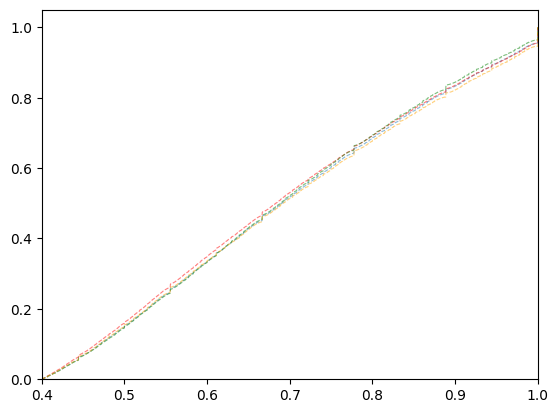

In [14]:
import matplotlib.pyplot as plt
peak_if_data = glac_df["Final IF"].dropna().values

# 2. sort and compute cumulative probabilities
cdf_x = np.sort(peak_if_data)
cdf_y = np.arange(1, cdf_x.size + 1) / cdf_x.size

# 2. sort and compute cumulative probabilities
filtered_peak_data=peak_if_data[glac_df["Glac_peak_ind"] < glac_df['track_length']/pd.Timedelta("15 minutes")]
cdf_x_not_end = np.sort(filtered_peak_data)
cdf_y_not_end = np.arange(1, cdf_x_not_end.size + 1) / cdf_x_not_end.size

filtered_peak_data=peak_if_data[glac_df["Hemisphere"]=="North"]
cdf_x_np = np.sort(filtered_peak_data)
cdf_y_np = np.arange(1, cdf_x_np.size + 1) / cdf_x_np.size

filtered_peak_data=peak_if_data[glac_df["Hemisphere"]=="South"]
cdf_x_sp = np.sort(filtered_peak_data)
cdf_y_sp = np.arange(1, cdf_x_sp.size + 1) / cdf_x_sp.size
# 3. plot
plt.step(cdf_x, cdf_y, where="post",label="All Glaciation Events",linewidth=0.8,linestyle="--", alpha=0.5)

# 3. plot
plt.step(cdf_x_not_end, cdf_y_not_end, where="post",label="Non-teminating",color="red",linestyle="--",linewidth=0.8, alpha=0.5)

# 3. plot
plt.step(cdf_x_np, cdf_y_np, where="post",label="Non-teminating",color="green",linestyle="--",linewidth=0.8, alpha=0.5)

# 3. plot
plt.step(cdf_x_sp, cdf_y_sp, where="post",label="Non-teminating",color="orange",linestyle="--",linewidth=0.8, alpha=0.5)
plt.ylim(0, 1.05)
plt.xlim(0.4, 1.0)

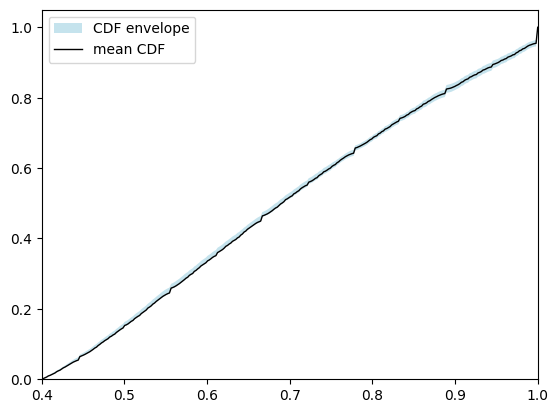

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. decide on a common x-grid
x_min, x_max = 0.4, 1.0
x_grid = np.linspace(x_min, x_max, 300)

# 2. interpolate each CDF onto x_grid
y_all     = np.interp(x_grid, cdf_x,         cdf_y,         left=0, right=1)
y_not_end = np.interp(x_grid, cdf_x_not_end, cdf_y_not_end, left=0, right=1)
y_np      = np.interp(x_grid, cdf_x_np,      cdf_y_np,      left=0, right=1)
y_sp      = np.interp(x_grid, cdf_x_sp,      cdf_y_sp,      left=0, right=1)

# 3. stack them and get the envelope
Ys    = np.vstack([y_all, y_not_end, y_np, y_sp])
lower = Ys.min(axis=0)
upper = Ys.max(axis=0)
mean  = Ys.mean(axis=0)

# 4. plot the envelope (draw it first!)
plt.fill_between(x_grid, lower, upper,
                 facecolor='lightblue', alpha=0.7,
                 label='CDF envelope')

# 5. (optional) add a central line if you like
plt.plot(x_grid, y_all, color='k', lw=1, ls='-',
         label='mean CDF')

# 6. then layer any other shaded bands or lines on top…
#    for instance your uncertainty band:
# plt.fill_between(x_grid, ci_lo, ci_hi,           # assuming ci_lo/ci_hi defined on x_grid
#                  facecolor='C0', alpha=0.2,
#                  label='95% CI')

# 7. final tweaks
plt.xlim(x_min, x_max)
plt.ylim(0, 1.05)
plt.legend(loc='best')
plt.show()


In [ ]:
filtered_df = lim_glac_df[lim_glac_df["avg_size[km]"]>1e3]
# sample = filtered_df.sample(1000, random_state=42)
# sample = filtered_df
sample = cloud_df[cloud_df["max_water_frac"]>0.4]#.sample(100000, random_state=42)
# temp_cloud = sample.iloc[0]

In [176]:
from numba import njit
# @njit
def haversine_list(lat_deg, lon_deg, out):
    R = 6_371_000.0
    n = lat_deg.shape[0]
    for i in range(n-1):
        φ1 = np.deg2rad(lat_deg[i])
        φ2 = np.deg2rad(lat_deg[i+1])
        Δφ = np.deg2rad(lat_deg[i+1] - lat_deg[i])
        Δλ = np.deg2rad(lon_deg[i+1] - lon_deg[i])
        a = np.sin(Δφ/2)**2 + np.cos(φ1)*np.cos(φ2)*np.sin(Δλ/2)**2
        out[i] = 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

In [177]:
np.sin(temp_cloud["avg_lat"] * np.pi / 180.0)

0.6023736571086911

In [178]:
sample.loc[:,"qual"] = True

In [179]:
def is_maritime(temp_cloud):
    if temp_cloud["avg_lat"] > 0:
        return temp_cloud["avg_lon"] < -10
    else:
        return True

In [180]:
def check_speed_anomalies(temp_cloud):
    out_arr = np.zeros(len(temp_cloud["lat_hist"])-1, dtype=np.float64)
    haversine_list(temp_cloud["lat_hist"],temp_cloud["lon_hist"],out_arr)
    size_change = temp_cloud["size_hist_km"][1:] - temp_cloud["size_hist_km"][:-1] 
    size_change = np.abs(size_change/(9/abs(np.sin(temp_cloud["avg_lat"])*np.pi/180.0)))*1000
    true_dist = out_arr - size_change/2
    speed= true_dist/(15*60)
    if (speed>115).any():
        return True
    else:
        return False

In [181]:
def check_size_anomalies(temp_cloud):
    lag = 4
    threshold = 5
    influence = 0
    ths_res = thresholding_algo(temp_cloud["size_hist_km"], lag=lag, threshold=threshold, influence=influence)
    if (ths_res["signals"]>0).any():
        return True
    else:
        return False

In [182]:
def is_near_temp_boundaries(sample):
    """ Check if the minimum or maximum temperature in the cloud sample is within 1 degree of any temperature boundary"""
    temp_boundaries = 273.15 + cloud_df.min_temp.unique()
    temp_boundaries = np.tile(temp_boundaries[np.newaxis,:],(sample.shape[0],1)) 
    min_temps = np.tile((sample["ctt_hist"]).map(np.min).to_numpy().T,(6,1)).T
    max_temps = np.tile((sample["ctt_hist"]).map(np.max).to_numpy().T,(6,1)).T
    dist_to_lower_bin = np.abs(temp_boundaries - min_temps).min(axis=1)
    dist_to_higher_bin = np.abs(temp_boundaries - max_temps).min(axis=1)
    return (dist_to_lower_bin<1) | (dist_to_higher_bin<1)

In [183]:
def is_stratiform(cloud_series: pd.Series) -> pd.Series:
    """
    Given a Series of cloud‐type names (possibly containing None/NaN),
    return a Boolean mask that’s True only for stratiform clouds.
    """
    stratiform = {
        "Altostratus",
        "Nimbostratus",
        "Cirrostratus",
        "Stratocumulus",
        "Stratus",
    }
    # .isin(...) yields False for None/NaN automatically
    return cloud_series.isin(stratiform)

In [184]:
def area_autocorrelation(temp_cloud):
    """
    Calculate the autocorrelation of the area of the cloud.
    """
    area = temp_cloud["size_hist_km"]
    n = len(area)
    mean_area = np.mean(area)
    c0 = np.var(area, ddof=0)  # Use ddof=0 for population variance
    # autocorr = np.zeros(n)
    # for lag in range(n):
    #     c_lag = np.sum((area[:n-lag] - mean_area) * (area[lag:] - mean_area)) / (n - lag)
    #     autocorr[lag] = c_lag / c0
    lag = 1
    c_lag = np.sum((area[:n-lag] - mean_area) * (area[lag:] - mean_area)) / (n - lag)
    autocorr = c_lag / c0
    return autocorr
def std_area(temp_cloud):
    """
    Calculate the standard deviation of the area of the cloud.
    """
    area = temp_cloud["size_hist_km"]
    return np.std(area, ddof=0)/np.mean(area)

In [185]:
sample.loc[:,"is_maritime"] = sample.apply(is_maritime, axis=1)

In [ ]:
# sample.loc[:,"autocorr"] = sample.apply(area_autocorrelation, axis=1)
# sample.loc[:,"std_area"] = sample.apply(std_area, axis=1)

/tmp/ipykernel_36248/3766905459.py:15: RuntimeWarning: invalid value encountered in scalar divide
  autocorr = c_lag / c0


In [188]:
# print(sample.loc[56172]["autocorr"],sample.loc[56172]["std_area"])

In [ ]:
# sample.loc[:,"area_index"] = (sample["std_area"]<0.1) | (sample["autocorr"]>0.9)
# sample["area_index"].value_counts(normalize=True)

area_index
False    0.96783
True     0.03217
Name: proportion, dtype: float64

In [190]:
# sample.loc[:,"speed_anom"] = sample.apply(check_speed_anomalies, axis=1)

In [191]:
# sample.loc[:,"size_anom"] = sample.apply(check_size_anomalies, axis=1)

In [192]:
sample.loc[:,"near_bounds"] = is_near_temp_boundaries(sample)

In [193]:
sample.loc[:, "is_stratiform"] = is_stratiform(sample["Cloud type"])

In [194]:
sample.loc[:,"qual"] = ~( sample["near_bounds"] | ~sample["is_stratiform"] | ~sample["is_maritime"])
sample["qual"].value_counts(normalize=True)

qual
False    0.77044
True     0.22956
Name: proportion, dtype: float64

In [195]:
# sample.loc[:,"qual"] = ~(sample["speed_anom"] | sample["size_anom"] | sample["near_bounds"] | ~sample["is_stratiform"] | ~sample["area_index"])
# sample["qual"].value_counts(normalize=True)

In [196]:
quality_clouds = sample[sample["qual"]==True]

In [197]:
quality_clouds["Cloud type"]

3215736     Nimbostratus
1215968    Stratocumulus
2186238     Nimbostratus
474069       Altostratus
3510570      Altostratus
               ...      
2013661     Cirrostratus
2161396      Altostratus
3781047      Altostratus
427734       Altostratus
309557       Altostratus
Name: Cloud type, Length: 22956, dtype: object

In [198]:
pole_temp_occ_rates = quality_clouds.groupby(["pole","min_temp"]).is_glaciating.mean()
temp_occ_rates = quality_clouds.groupby(["min_temp"]).is_glaciating.mean()
pole_temp_occ_rates

pole  min_temp
np    -36         0.174479
      -30         0.139744
      -24         0.090373
      -18         0.053991
      -12         0.012440
      -6          0.000000
sp    -36         0.171429
      -30         0.077472
      -24         0.047951
      -18         0.027219
      -12         0.006634
      -6          0.000000
Name: is_glaciating, dtype: float64

In [199]:
pole_temp_occ_rates = pole_temp_occ_rates.reset_index()
temp_occ_rates = temp_occ_rates.reset_index()

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:

<Axes: xlabel='min_temp', ylabel='is_glaciating'>

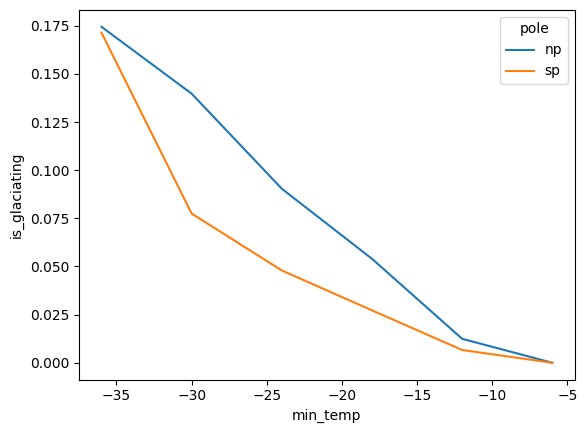

In [200]:
sns.lineplot(data = pole_temp_occ_rates, x = "min_temp", y= "is_glaciating", hue="pole")

In [201]:
# quality_clouds.to_parquet("/wolke_scratch/dnikolo/Final_results/high_quality_clouds_2010.parquet")

In [202]:
# temp_occ_rates.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/High_qual_temp_occ_rates.csv")
# pole_temp_occ_rates.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/High_qual_pole_temp_occ_rates.csv")

In [207]:
# temp_occ_rates.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/.csv")
pole_temp_occ_rates.to_csv("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/hq_pole_temp_occurance_rate_glac_possible.csv")

## 2. Visualize high quality glaciations

In [203]:
import matplotlib.pyplot as plt

import xarray as xr

In [204]:
def set_glac_properties(sample_glac):
    sample_glac["glaciation_start_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*sample_glac["Glac_start_ind"]
    sample_glac["glaciation_end_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*(sample_glac["Glac_peak_ind"]+1)
    sample_glac["track_end_time"] = sample_glac["track_start_time"]+ sample_glac["track_length"]

In [205]:
cloud_id = 3

In [206]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from matplotlib import colors as mcolors

# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------

# for cloud_id in range(len(sample_glac)):
# cloud = sample_glac.iloc[cloud_id]
cloud = sample[(sample["qual"]==True) & (sample.min_temp==-30)].iloc[4]
# cloud = glac_df.loc[56172]
set_glac_properties(cloud)
# 2) Grab its start/end times
t0 = cloud.track_start_time
t1 = cloud.track_end_time 

# 4) Make sure your Dataset’s time coordinate is in datetime64:
#    (optional sanity check)
tracking_data['time'] = tracking_data.indexes['time']
# 5) Slice the Dataset in time and select the right track:
# sub = tracking_data.sel(
#     time=slice(t0, t1)
# )
sub = tracking_data.sel(
    time=slice(t0, t1)
)
# 6) Pull out the feature_number variable
feat_vals = sub['tracknumber'].values
cph_vals = sub["cph_filtered"].values
initial_mat = feat_vals[0]
end_mat = feat_vals[-1]
# print(len(initial_mat[initial_mat==(cloud["tracknumber"])]), cloud["avg_size[px]"], cloud["min_size[px]"], cloud["max_size[px]"])
size_change= len(initial_mat[initial_mat==(cloud["tracknumber"])])-len(end_mat[end_mat==(cloud["tracknumber"])])
t, x,y = np.where(feat_vals==cloud["tracknumber"])





# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------

track_id = cloud["tracknumber"]
n_frames, H, W = cph_vals.shape

# 1) Mask out everything except the target cloud:
masked_cph = np.full_like(cph_vals, np.nan, dtype=float)
for t in range(n_frames):
    mask = (feat_vals[t] == track_id)
    masked_cph[t] = np.where(mask, cph_vals[t], np.nan)

# 2) Find the bounding box (over all time steps) of non-NaN pixels:
ys, xs = np.where(np.any(~np.isnan(masked_cph), axis=0))
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

# 3) Expand the bounding box by a few pixels:
frame_width = 1
y0 = max(y_min - frame_width, 0)
y1 = min(y_max + 1 + frame_width, H)
x0 = max(x_min - frame_width, 0)
x1 = min(x_max + 1 + frame_width, W)

cropped = cph_vals[:, y0:y1, x0:x1]
cropped_masked = masked_cph[:, y0:y1, x0:x1]
h_crop, w_crop = cropped.shape[1], cropped.shape[2]

# 4) Precompute RGB triplets for the palette
red_rgb   = np.array(mcolors.to_rgb('#e41a1c'))
blue_rgb  = np.array(mcolors.to_rgb('#377eb8'))
green_rgb = np.array(mcolors.to_rgb('#4daf4a'))
white_rgb = np.array([1.0, 1.0, 1.0])

# Function to build an RGB image for a given frame
def make_rgba_frame(frame_idx):
    frame_cph       = cropped[frame_idx]
    frame_cph_cloud = cropped_masked[frame_idx]
    rgb = np.ones((h_crop, w_crop, 3), dtype=float)  # start white

    # Cloud pixels with cph >= 1: interpolate from red to blue
    cloud_mask = ~np.isnan(frame_cph_cloud) & (frame_cph_cloud >= 1)
    if np.any(cloud_mask):
        vals = frame_cph_cloud[cloud_mask]
        t = (vals - 1.0) / 1.0  # normalize 1→0, 2→1
        inter = np.outer(1 - t, red_rgb) + np.outer(t, blue_rgb)
        rgb[cloud_mask] = inter

    # Outside-cloud pixels (i.e., where frame_cph_cloud is NaN) with cph > 1: set green
    outside_mask = np.isnan(frame_cph_cloud) & (frame_cph > 1)
    rgb[outside_mask] = white_rgb#np.array([0,0,0])
    # print(rgb.shape)
    return rgb

# 5) Set up the figure with the first frame’s RGB
fig, ax = plt.subplots(figsize=(8, 4))
initial_rgb = make_rgba_frame(0)
im = ax.imshow(initial_rgb, interpolation="none",
            extent=(x0, x1, y1, y0))  # keep original coordinates
ax.set_title(f"Cloud {track_id} CPH Evolution (custom palette)")
ax.axis("off")
i=0
def update(frame):
    current_frame = make_rgba_frame(frame)
    im.set_data(current_frame)
    ax.set_xlabel(f"Time step: {frame}")
    # fig.savefig(f'fig{i}.png')
    return [im]

anim = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=300,   # milliseconds between frames
    blit=True
)
# with open(f"/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Tracking_quality_evidence/glaciation_video_{cloud_id}.html", "w") as f:
#     print(anim.to_html5_video(), file=f)
# Display inline in Jupyter:
HTML(anim.to_html5_video())

KeyError: 'Glac_start_ind'

## 3. Testing

In [ ]:
sample["qual"].value_counts()

qual
False    1481
True      989
Name: count, dtype: int64

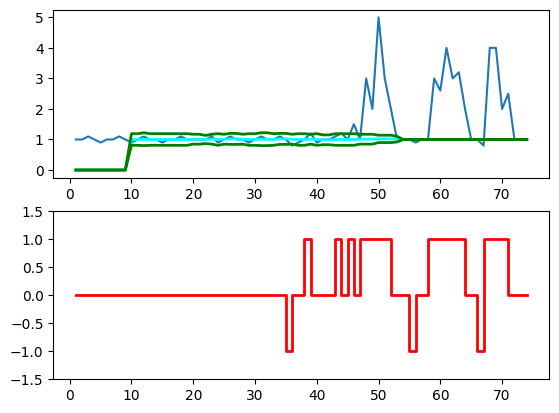

In [ ]:
# From 
# Data
y = np.array([1,1,1.1,1,0.9,1,1,1.1,1,0.9,1,1.1,1,1,0.9,1,1,1.1,1,1,1,1,1.1,0.9,1,1.1,1,1,0.9,
       1,1.1,1,1,1.1,1,0.8,0.9,1,1.2,0.9,1,1,1.1,1.2,1,1.5,1,3,2,5,3,2,1,1,1,0.9,1,1,3,
       2.6,4,3,3.2,2,1,1,0.8,4,4,2,2.5,1,1,1])

# Settings: lag = 30, threshold = 5, influence = 0
lag = 10
threshold = 3
influence = 0

# Run algo with settings from above
result = thresholding_algo(y, lag=lag, threshold=threshold, influence=influence)

# Plot result
pylab.subplot(211)
pylab.plot(np.arange(1, len(y)+1), y)

pylab.plot(np.arange(1, len(y)+1),
           result["avgFilter"], color="cyan", lw=2)

pylab.plot(np.arange(1, len(y)+1),
           result["avgFilter"] + threshold * result["stdFilter"], color="green", lw=2)

pylab.plot(np.arange(1, len(y)+1),
           result["avgFilter"] - threshold * result["stdFilter"], color="green", lw=2)

pylab.subplot(212)
pylab.step(np.arange(1, len(y)+1), result["signals"], color="red", lw=2)
pylab.ylim(-1.5, 1.5)
pylab.show()
